# Random Forest Regressor

## Setup

In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error , r2_score

from sklearn.ensemble import RandomForestRegressor


In [2]:
# Load arrays from the compressed archive
data = np.load('datasets/processed_splits.npz')

X_tr_scaled = data['X_tr']
y_tr_scaled = data['y_tr_scaled']
y_tr = data['y_tr']
X_val_scaled = data['X_val']
y_val = data['y_val']

# import exact scaler instance from the preprocessing notebook
target_scaler = joblib.load('datasets/target_scaler.joblib')
print('All data successfully imported.')


All data successfully imported.


## Training

search for best combination of selected hyperparameters : no. of trees, tree depth, randomness of decision trees

two parts to search: random search through ranges, then a grid search on narrowed down range of parameters

Random search using cross validation

In [3]:
rf_model = RandomForestRegressor(random_state=42)

# ramdom search radius using wide ranges in hyperparameters
param_random = { # explain in report why these were hard coded to the current values, reference the physics problem
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30],
    'max_features': [10, 20, 30, 40, 50, 100]
}

# initialize random search using cross-validation
# NOTE: without CPU parallelization, iterations=50 takes about 20 mins to run
random_search = RandomizedSearchCV(
    estimator = rf_model,
    param_distributions = param_random,
    n_iter= 50,
    scoring ='r2',
    cv = 5,
    random_state = 42,
    n_jobs=-1 # CPU parallelization
)

random_search.fit(X_tr_scaled, y_tr_scaled)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': [10, 20, ...], 'n_estimators': array([ 50, 1...50, 200, 250])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``

In [4]:
# Random Forest - Random Search quantification metrics
print("Random Search - Optimal Hyperparameters: ", random_search.best_params_)

# select best performing rf from random search, make predictions and unscale
best_rf_random = random_search.best_estimator_
y_pred_rf_random_scaled_tr = best_rf_random.predict(X_tr_scaled)
y_pred_rf_random_scaled = best_rf_random.predict(X_val_scaled)
y_pred_rf_random_unscaled_tr = target_scaler.inverse_transform(y_pred_rf_random_scaled_tr)
y_pred_rf_random_unscaled = target_scaler.inverse_transform(y_pred_rf_random_scaled)

# validation and training sets
rf_random_r2_tr = r2_score(y_tr, y_pred_rf_random_unscaled_tr, multioutput='raw_values')
rf_random_r2_val = r2_score(y_val, y_pred_rf_random_unscaled, multioutput='raw_values')

print("R^2 Score | Training | Validation")
print(f'Kappa | {rf_random_r2_tr[0]:.3f} | {rf_random_r2_val[0]:.3f}')
print(f'Beta | {rf_random_r2_tr[1]:.3f} | {rf_random_r2_val[1]:.3f}')


Random Search - Optimal Hyperparameters:  {'n_estimators': np.int64(250), 'max_features': 20, 'max_depth': 20}
R^2 Score | Training | Validation
Kappa | 0.999 | 0.995
Beta | 0.992 | 0.948


In [5]:
# extract best performing hyperparameters from the random search
best_n_estimators = random_search.best_params_['n_estimators']
best_max_depth = random_search.best_params_['max_depth']
best_max_features = random_search.best_params_['max_features']


Gridsearch using best performing random search parameters

In [6]:
# grid search in narrowed radius based on optimal random search results
param_grid = {
    'n_estimators': [best_n_estimators-20, best_n_estimators, best_n_estimators+20],
    # The max(1, ...) prevents it from accidentally asking for -1 features if best_features was very low.
    'max_features': [max(1, best_max_features-2), best_max_features, best_max_features+2]
}

# prevent error in edge case scenario that max_depth is None
if best_max_depth is None:
    param_grid['max_depth'] = [None, 40, 50]
else:
    param_grid['max_depth'] = [best_max_depth-5, best_max_depth, best_max_depth+5]

# initialize grid search using cross validation
grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 5,
    n_jobs=-1
    # verbose = 2
)

grid_search.fit(X_tr_scaled, y_tr_scaled)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [15, 20, ...], 'max_features': [18, 20, ...], 'n_estimators': [np.int64(230), np.int64(250), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [7]:
# Random Forest - Grid Search quantification metrics

print("Grid Search - Best Parameters: ", grid_search.best_params_)

best_rf_grid = grid_search.best_estimator_
y_pred_rf_grid_scaled_tr = best_rf_grid.predict(X_tr_scaled)
y_pred_rf_grid_scaled = best_rf_grid.predict(X_val_scaled)
y_pred_rf_grid_unscaled_tr = target_scaler.inverse_transform(y_pred_rf_grid_scaled_tr)
y_pred_rf_grid_unscaled = target_scaler.inverse_transform(y_pred_rf_grid_scaled)

# validation and training sets
rf_grid_r2_tr = r2_score(y_tr, y_pred_rf_grid_unscaled_tr, multioutput='raw_values')
rf_grid_r2_val = r2_score(y_val, y_pred_rf_grid_unscaled, multioutput='raw_values')

print("R^2 Score | Training | Validation")
print(f'Kappa | {rf_grid_r2_tr[0]:.3f} | {rf_grid_r2_val[0]:.3f}')
print(f'Beta | {rf_grid_r2_tr[1]:.3f} | {rf_grid_r2_val[1]:.3f}')


Grid Search - Best Parameters:  {'max_depth': 15, 'max_features': 20, 'n_estimators': np.int64(230)}
R^2 Score | Training | Validation
Kappa | 0.999 | 0.995
Beta | 0.992 | 0.947


In [8]:
# extract the best performing hyperparameters from the grid search
best_n_estimators = grid_search.best_params_['n_estimators']
best_max_depth = grid_search.best_params_['max_depth']
best_max_features = grid_search.best_params_['max_features']


## Final Model

Create and run the optimized random forest

In [9]:
# initialize the random forest using optimial hyperparameters from training stage and fit to training set
rf_model = RandomForestRegressor(
    n_estimators=best_n_estimators, 
    max_depth=best_max_depth,
    max_features=best_max_features,
    random_state=42
)

rf_model.fit(X_tr_scaled, y_tr_scaled)

# make predictions on training and validation sets and undo target scaling
y_pred_rf_scaled_tr = rf_model.predict(X_tr_scaled)
y_pred_rf_scaled = rf_model.predict(X_val_scaled)
y_pred_rf_tr = target_scaler.inverse_transform(y_pred_rf_scaled_tr)
y_pred_rf = target_scaler.inverse_transform(y_pred_rf_scaled)


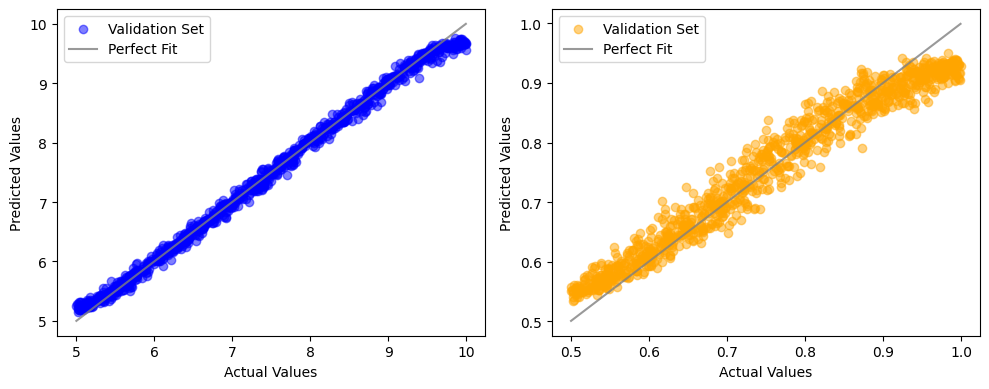

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# plot kappa predictions using optimal Random Forest model
ax1.scatter(y_val[:,0], y_pred_rf[:,0], color='blue', alpha=0.5, label='Validation Set')
# line of perfect fit (y=x)
ideal_line_kappa = np.linspace(min(y_val[:,0]), max(y_val[:,0]), 100)
ax1.plot(ideal_line_kappa, ideal_line_kappa, color='grey', alpha=0.8, label='Perfect Fit')

ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.legend()

# plot beta predictions using optimal Random Forest model
ax2.scatter(y_val[:,1], y_pred_rf[:,1], color='orange', alpha=0.5, label='Validation Set')
# line of perfect fit (y=x)
ideal_line_beta = np.linspace(min(y_val[:,1]), max(y_val[:,1]), 100)
ax2.plot(ideal_line_beta, ideal_line_beta, color='grey', alpha=0.8, label='Perfect Fit')

ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.legend()

plt.tight_layout()
plt.show()


In [11]:
# Random Forest quantification metrics

# validation set
rf_kappa_rmse_val = root_mean_squared_error(y_val[:,0], y_pred_rf[:,0])
rf_kappa_mse_val = mean_squared_error(y_val[:,0], y_pred_rf[:,0])
rf_kappa_r2_val = r2_score(y_val[:,0], y_pred_rf[:,0])

rf_beta_rmse_val = root_mean_squared_error(y_val[:,1], y_pred_rf[:,1])
rf_beta_mse_val = mean_squared_error(y_val[:,1], y_pred_rf[:,1])
rf_beta_r2_val = r2_score(y_val[:,1], y_pred_rf[:,1])

# training set
rf_kappa_rmse_tr = root_mean_squared_error(y_tr[:,0], y_pred_rf_tr[:,0])
rf_kappa_mse_tr = mean_squared_error(y_tr[:,0], y_pred_rf_tr[:,0])
rf_kappa_r2_tr = r2_score(y_tr[:,0], y_pred_rf_tr[:,0])

rf_beta_rmse_tr = root_mean_squared_error(y_tr[:,1], y_pred_rf_tr[:,1])
rf_beta_mse_tr = mean_squared_error(y_tr[:,1], y_pred_rf_tr[:,1])
rf_beta_r2_tr = r2_score(y_tr[:,1], y_pred_rf_tr[:,1])

print('\nKappa | Training | Validation')
print('------------------------------')
print(f'RMSE | {rf_kappa_rmse_tr:.3f} | {rf_kappa_rmse_val:.3f}')
print(f'MSE | {rf_kappa_mse_tr:.3f} | {rf_kappa_mse_val:.3f}')
print(f'R^2 | {rf_kappa_r2_tr:.3f} | {rf_kappa_r2_val:.3f}')

print('\nBeta | Training | Validation')
print('------------------------------')
print(f'RMSE | {rf_beta_rmse_tr:.3f} | {rf_beta_rmse_val:.3f}')
print(f'MSE | {rf_beta_mse_tr:.3f} | {rf_beta_mse_val:.3f}')
print(f'R^2 | {rf_beta_r2_tr:.3f} | {rf_beta_r2_val:.3f}')



Kappa | Training | Validation
------------------------------
RMSE | 0.039 | 0.101
MSE | 0.001 | 0.010
R^2 | 0.999 | 0.995

Beta | Training | Validation
------------------------------
RMSE | 0.013 | 0.034
MSE | 0.000 | 0.001
R^2 | 0.992 | 0.947


Save the optimized Random Forest regressor for comparison with other models

In [12]:
joblib.dump(rf_model, 'models/rf_model.joblib')
print('Optimized Random Forest model saved')


Optimized Random Forest model saved
